## 目录
- 第2章：概述、线性代数和 NDArray
- 第3章：概率与统计
- 第4章：导数、反向传播和复杂度
- 第5章：线性方法、基础优化和 softmax 回归
- 第6章：最大似然估计和逻辑回归

## 第2章：线性代数理论题与编程题
已知向量 a=[2, -1, 3]^T, b=[1,4,-2]^T，矩阵
A=[[1,0,2],[-1,3,1]]， B=[[2,1],[0,-1],[3,2]]

In [1]:
import numpy as np
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
A = np.array([[1,0,2],[-1,3,1]])
B = np.array([[2,1],[0,-1],[3,2]])
# 1. 向量点积 a·b
dot_ab = a.dot(b)
# 2. 矩阵乘法 A x B
AXB = A.dot(B)
# 3. 向量 a 的 Frobenius 范数（即 Euclidean 范数）
fro_a = np.linalg.norm(a)
dot_ab, AXB, AXB.shape, fro_a

(-8,
 array([[ 8,  5],
        [ 1, -2]]),
 (2, 2),
 3.7416573867739413)

### 第2章 编程题：NumPy 操作
1. 创建 3x4 的随机矩阵 X（标准正态分布）
2. 创建 4x2 的全1矩阵 Y
3. 计算 Z = X × Y，输出 Z 的第1行第2列元素，以及 Z 的第2行所有元素；计算 Z 的 Frobenius 范数。

In [2]:
rng = np.random.default_rng(42)
X = rng.standard_normal((3,4))
Y = np.ones((4,2))
Z = X.dot(Y)
elem_1_2 = Z[0,1]  # 第1行第2列（0-based 索引）
row2 = Z[1,:]     # 第2行所有元素
fro_Z = np.linalg.norm(Z, 'fro')
X, Y, Z, elem_1_2, row2, fro_Z

(array([[ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472],
        [-1.95103519, -1.30217951,  0.1278404 , -0.31624259],
        [-0.01680116, -0.85304393,  0.87939797,  0.77779194]]),
 array([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]]),
 array([[ 0.95574889,  0.95574889],
        [-3.44161688, -3.44161688],
        [ 0.78734483,  0.78734483]]),
 0.955748885711607,
 array([-3.44161688, -3.44161688]),
 5.172638511887385)

## 第3章：概率与统计（中心极限定理模拟）
题目：生成 n=10000 个 U(0,1) 随机变量，重复 m=1000 次，每次计算这 n 个变量的均值，绘制直方图并与正态分布密度曲线比较，计算这些均值的实际方差。

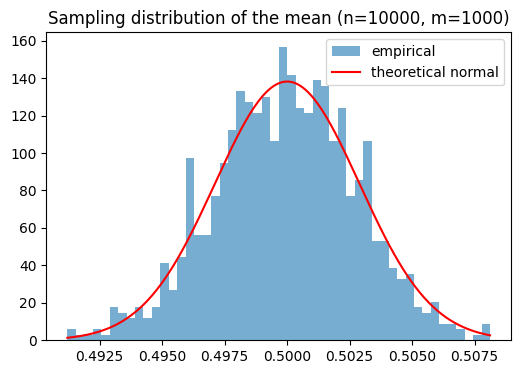

(0.49991980166118877, 7.99846428868118e-06, 0.5, 8.333333333333332e-06)

In [3]:
import matplotlib.pyplot as plt
n = 10000
m = 1000
means = []
for _ in range(m):
    s = rng.random(n)
    means.append(s.mean())
means = np.array(means)
emp_mean = means.mean()
emp_var = means.var(ddof=0)
# 理论：每个 U(0,1) 的均值为 0.5，方差为 1/12，样本均值方差 = (1/12)/n
theo_var = (1/12) / n
theo_mean = 0.5
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(means, bins=50, density=True, alpha=0.6, label='empirical')
xs = np.linspace(means.min(), means.max(), 200)
from math import sqrt, pi
def normal_pdf(x, mu, sigma):
    return 1.0/(sigma*sqrt(2*pi)) * np.exp(-0.5*((x-mu)/sigma)**2)
ax.plot(xs, normal_pdf(xs, theo_mean, np.sqrt(theo_var)), 'r', label='theoretical normal')
ax.set_title('Sampling distribution of the mean (n=10000, m=1000)')
ax.legend()
plt.show()
emp_mean, emp_var, theo_mean, theo_var

## 第4章：导数与反向传播
给定 z=(w1*x1 + w2*x2 - y)^2，求对 w1、w2 的偏导并在 w1=0.5, w2=1, x1=2, x2=1, y=3 时计算梯度值。

In [4]:
# 符号推导（手写）:
# z = (w1 x1 + w2 x2 - y)^2, 令 u = w1 x1 + w2 x2 - y, z = u^2
# dz/dw1 = 2 u * x1, dz/dw2 = 2 u * x2
w1 = 0.5
w2 = 1.0
x1 = 2.0
x2 = 1.0
y = 3.0
u = w1*x1 + w2*x2 - y
dz_dw1 = 2*u*x1
dz_dw2 = 2*u*x2
u, dz_dw1, dz_dw2

(-1.0, -4.0, -2.0)

手动实现简单前向计算并用数值微分验证：
定义前向：输入 x，经过 a = x * w1，b = a + w2，输出 L = b^2。给定 x=2, w1=1.5, w2=0.5，计算前向值和关于 w1,w2 的梯度（解析与数值验证）。

In [5]:
def forward(x, w1, w2):
    a = x * w1
    b = a + w2
    L = b**2
    return L, a, b
x = 2.0
w1 = 1.5
w2 = 0.5
L, a, b = forward(x, w1, w2)
# 解析梯度: dL/db = 2b, db/dw2 = 1, db/dw1 = x => dL/dw2 = 2b, dL/dw1 = 2b * x
dL_db = 2*b
dL_dw2 = dL_db * 1
dL_dw1 = dL_db * x
# 数值近似
def num_grad_w(func, param_name, eps=1e-6):
    if param_name=='w1':
        Lp = func(x, w1+eps, w2)[0]
        Lm = func(x, w1-eps, w2)[0]
    else:
        Lp = func(x, w1, w2+eps)[0]
        Lm = func(x, w1, w2-eps)[0]
    return (Lp-Lm)/(2*eps)
num_dL_dw1 = num_grad_w(forward, 'w1')
num_dL_dw2 = num_grad_w(forward, 'w2')
L, dL_dw1, dL_dw2, num_dL_dw1, num_dL_dw2

(12.25, 14.0, 7.0, 13.999999998404178, 7.000000000978446)

## 第5章：softmax 回归（手写实现）
使用 sklearn.datasets.load_digits 或自已加载 MNIST 子集；将像素展开为向量，对标签做 one-hot 编码；实现 softmax + 交叉熵，并用小批量 SGD 训练，输出测试集准确率。为速度考虑使用 digits 数据集。

In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
data = load_digits()
X = data.data.astype(np.float32)
y = data.target
# 标准化
scaler = StandardScaler()
X = scaler.fit_transform(X)
# 划分训练/测试
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
n_classes = len(np.unique(y))
# one-hot
enc = OneHotEncoder(sparse=False, categories='auto')
Y_train = enc.fit_transform(y_train.reshape(-1,1))
Y_test = enc.transform(y_test.reshape(-1,1))
# 模型参数初始化
D = X_train.shape[1]
W = np.zeros((D, n_classes))
b = np.zeros(n_classes)
def softmax_logits(logits):
    e = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)
def cross_entropy(probs, Y):
    return -np.sum(Y * np.log(probs + 1e-12)) / probs.shape[0]
# 训练超参
epochs = 50
lr = 0.1
batch_size = 32
n_train = X_train.shape[0]
for epoch in range(epochs):
    perm = rng.permutation(n_train)
    for i in range(0, n_train, batch_size):
        idx = perm[i:i+batch_size]
        xb = X_train[idx]
        yb = Y_train[idx]
        logits = xb.dot(W) + b
        probs = softmax_logits(logits)
        # gradient
        grad_logits = (probs - yb) / xb.shape[0]
        grad_W = xb.T.dot(grad_logits)
        grad_b = grad_logits.sum(axis=0)
        W -= lr * grad_W
        b -= lr * grad_b
    # 每个 epoch 计算训练/测试损失与准确率（可选）
    if (epoch+1) % 10 == 0 or epoch==0:
        train_probs = softmax_logits(X_train.dot(W)+b)
        test_probs = softmax_logits(X_test.dot(W)+b)
        train_loss = cross_entropy(train_probs, Y_train)
        test_loss = cross_entropy(test_probs, Y_test)
        train_acc = (train_probs.argmax(axis=1)==y_train).mean()
        test_acc = (test_probs.argmax(axis=1)==y_test).mean()
        print(f'Epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}, test_acc={test_acc:.4f}')
# 最终测试准确率
final_test_acc = (softmax_logits(X_test.dot(W)+b).argmax(axis=1) == y_test).mean()
final_test_acc

Epoch 1/50: train_loss=0.4643, test_loss=0.4712, test_acc=0.9222
Epoch 10/50: train_loss=0.1279, test_loss=0.1556, test_acc=0.9611
Epoch 20/50: train_loss=0.0871, test_loss=0.1270, test_acc=0.9694
Epoch 30/50: train_loss=0.0690, test_loss=0.1165, test_acc=0.9722
Epoch 40/50: train_loss=0.0581, test_loss=0.1108, test_acc=0.9750
Epoch 50/50: train_loss=0.0506, test_loss=0.1081, test_acc=0.9750


c:\Users\16230\.conda\envs\ttt\Lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


0.975

## 第6章：最大似然估计与逻辑回归
理论：对正态分布样本写出似然函数 L(μ, σ^2) 并推导 μ 与 σ^2 的最大似然解；编程：实现二分类逻辑回归（不使用高阶框架），生成两类线性可分数据并训练参数。

似然函数（简述）：若 x_i ~ N(μ, σ^2)，则对数似然 l = -n/2 log(2π) - n log σ - (1/(2σ^2)) Σ (x_i-μ)^2 。对 μ 求导并令为0 得 μ_hat = (1/n) Σ x_i；对 σ^2 求导得 σ^2_hat = (1/n) Σ (x_i-μ)^2 。

In [7]:
# 生成二分类数据并实现 logistic 回归（sigmoid + 二元交叉熵 + SGD）
def sigmoid(z):
    return 1/(1+np.exp(-z))
# 生成数据
rng2 = np.random.default_rng(1)
N = 200
D = 2
# 类别0: 均值 (-1, -1)， 类别1: 均值 (1,1)， 方差相同
X0 = rng2.normal(loc=-1.0, scale=1.0, size=(N//2, D))
X1 = rng2.normal(loc=1.0, scale=1.0, size=(N//2, D))
X_lr = np.vstack([X0, X1])
y_lr = np.hstack([np.zeros(N//2), np.ones(N//2)])
# 初始化参数
w = np.zeros(D)
b_lr = 0.0
lr = 0.1
epochs = 1000
for epoch in range(epochs):
    # 全量梯度（简单实现）
    logits = X_lr.dot(w) + b_lr
    preds = sigmoid(logits)
    error = preds - y_lr
    grad_w = X_lr.T.dot(error) / N
    grad_b = error.mean()
    w -= lr * grad_w
    b_lr -= lr * grad_b
# 训练后精度
pred_labels = (sigmoid(X_lr.dot(w)+b_lr) >= 0.5).astype(int)
acc = (pred_labels == y_lr).mean()
w, b_lr, acc

(array([2.75160286, 2.83759316]), 0.2811818534807128, 0.965)